In [ ]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set training url
training_url = 'https://raw.githubusercontent.com/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/refs/heads/main/dataset_A_training.csv'

# Import dataset for EDA
df_vaccine = pd.read_csv(training_url)

df_vaccine.set_index('respondent_id', inplace=True)

In [ ]:
# Shape of the dataset
print(f'Data has {df_vaccine.shape[0]} rows and {df_vaccine.shape[1]} columns')

Data has 4756 rows and 30 columns


In [ ]:
# Preview
df_vaccine.sample(10)

,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
2115,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,wholesale,0
3907,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Male,"> $75,000",Not Married,Rent,Employed,"MSA, Principle City",0.0,0.0,wholesale,0
2228,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,...,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,mining,0
2102,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Rent,Employed,"MSA, Not Principle City",1.0,2.0,hospitality,0
1418,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Female,NaN,NaN,NaN,NaN,Non-MSA,1.0,3.0,NaN,0
2907,3.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,mining,0
79,3.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,Non-MSA,1.0,0.0,NaN,0
2257,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,healthcare,1
1377,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,Male,"> $75,000",Married,Rent,Employed,"MSA, Not Principle City",1.0,2.0,education,0


In [ ]:
# General overview of the dataset
df_vaccine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4756 entries, 1 to 4756
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   flu_concern                  4744 non-null   float64
 1   flu_knowledge                4733 non-null   float64
 2   behavioral_antiviral_meds    4742 non-null   float64
 3   behavioral_avoidance         4724 non-null   float64
 4   behavioral_face_mask         4753 non-null   float64
 5   behavioral_wash_hands        4748 non-null   float64
 6   behavioral_large_gatherings  4747 non-null   float64
 7   behavioral_outside_home      4747 non-null   float64
 8   behavioral_touch_face        4737 non-null   float64
 9   doctor_recc_seasonal         4435 non-null   float64
 10  chronic_med_condition        4568 non-null   float64
 11  child_under_6_months         4604 non-null   float64
 12  health_worker                4607 non-null   float64
 13  health_insurance       

In [ ]:
# Statistical Summary
df_vaccine.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
flu_concern,4744.0,1.64,0.92,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,1.29,0.62,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,0.05,0.22,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,0.73,0.44,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,0.84,0.37,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,0.37,0.48,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,0.69,0.46,0.0,0.0,1.0,1.0,1.0
doctor_recc_seasonal,4435.0,0.37,0.48,0.0,0.0,0.0,1.0,1.0


 25 columns have missing values:


,Missing Count,Missing %
employment_sector,2314,48.65
health_insurance,1925,40.48
income_poverty,790,16.61
rent_or_own,381,8.01
doctor_recc_seasonal,321,6.75
education,270,5.68
employment_status,269,5.66
marital_status,265,5.57
chronic_med_condition,188,3.95
child_under_6_months,152,3.20


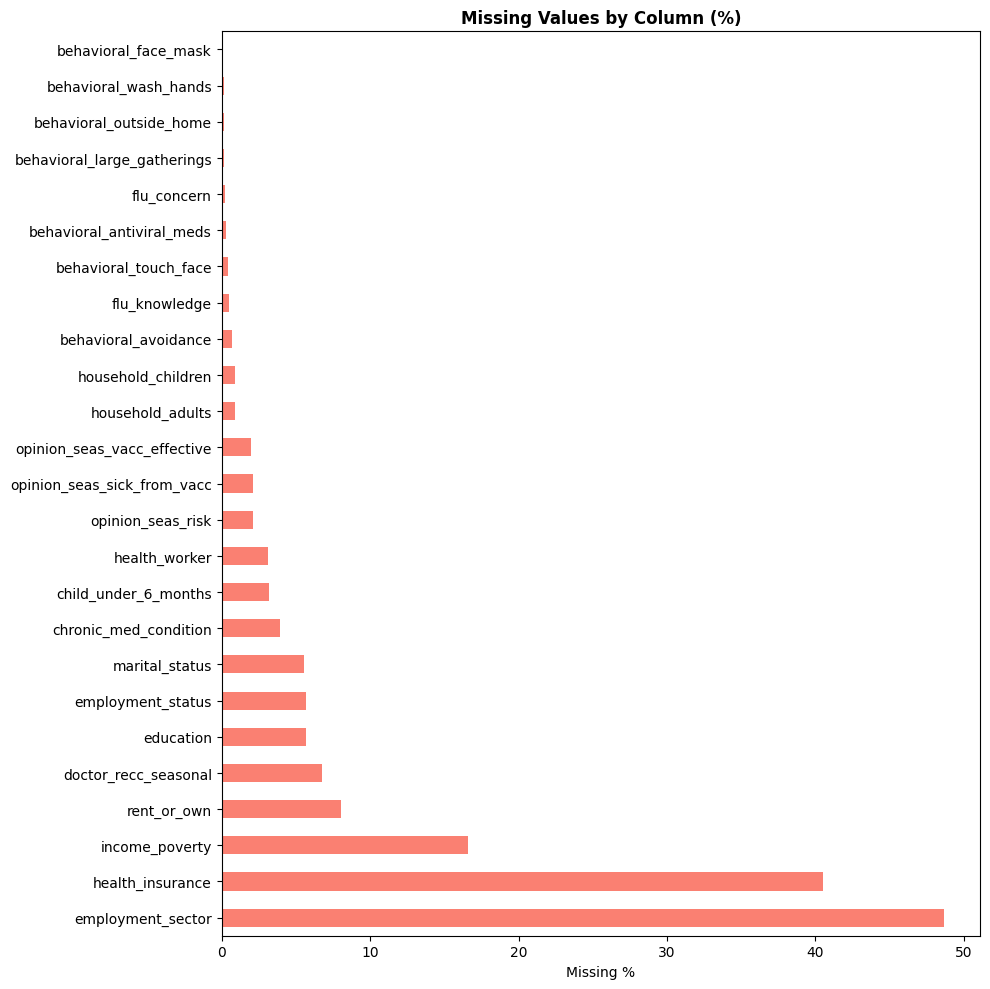

In [ ]:
# Missing Values Analysis
missing = df_vaccine.isnull().sum()
missing_pct = (missing / len(df_vaccine) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print('No missing values found!')
else:
    print(f' {len(missing_df)} columns have missing values:')
    display(missing_df)

    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Missing Values by Column (%)', fontweight='bold')
    ax.set_xlabel('Missing %')
    plt.tight_layout()
    plt.show()

 Classes are reasonably balanced (ratio: 1.2x)


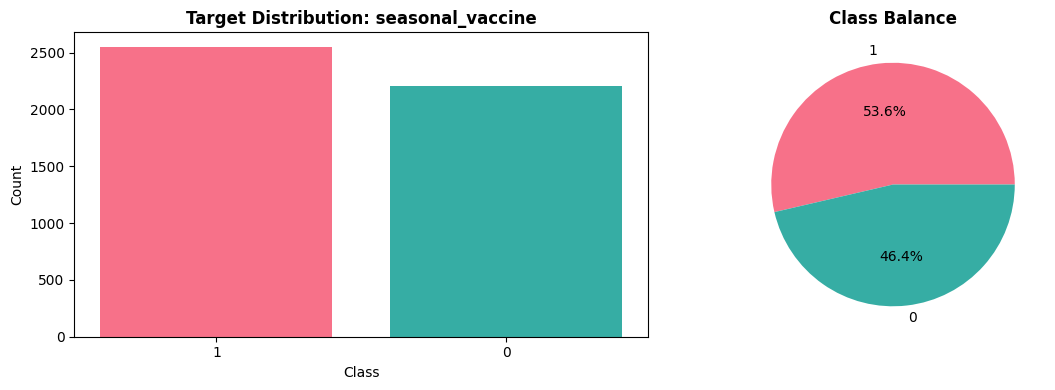

In [ ]:
Target_variable = 'seasonal_vaccine'
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution plot
if df_vaccine[Target_variable].dtype == 'object' or df_vaccine[Target_variable].nunique() < 15:
    # Classification
    counts = df_vaccine[Target_variable].value_counts()
    axes[0].bar(counts.index.astype(str), counts.values, color=sns.color_palette('husl', len(counts)))
    axes[0].set_title(f'Target Distribution: {Target_variable}', fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')

    axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%',
                colors=sns.color_palette('husl', len(counts)))
    axes[1].set_title('Class Balance', fontweight='bold')

    # Check imbalance
    imbalance_ratio = counts.max() / counts.min()
    if imbalance_ratio > 3:
        print(f'  Class imbalance detected! Ratio: {imbalance_ratio:.1f}x — consider class_weight="balanced"')
    else:
        print(f' Classes are reasonably balanced (ratio: {imbalance_ratio:.1f}x)')
plt.tight_layout()
plt.show()

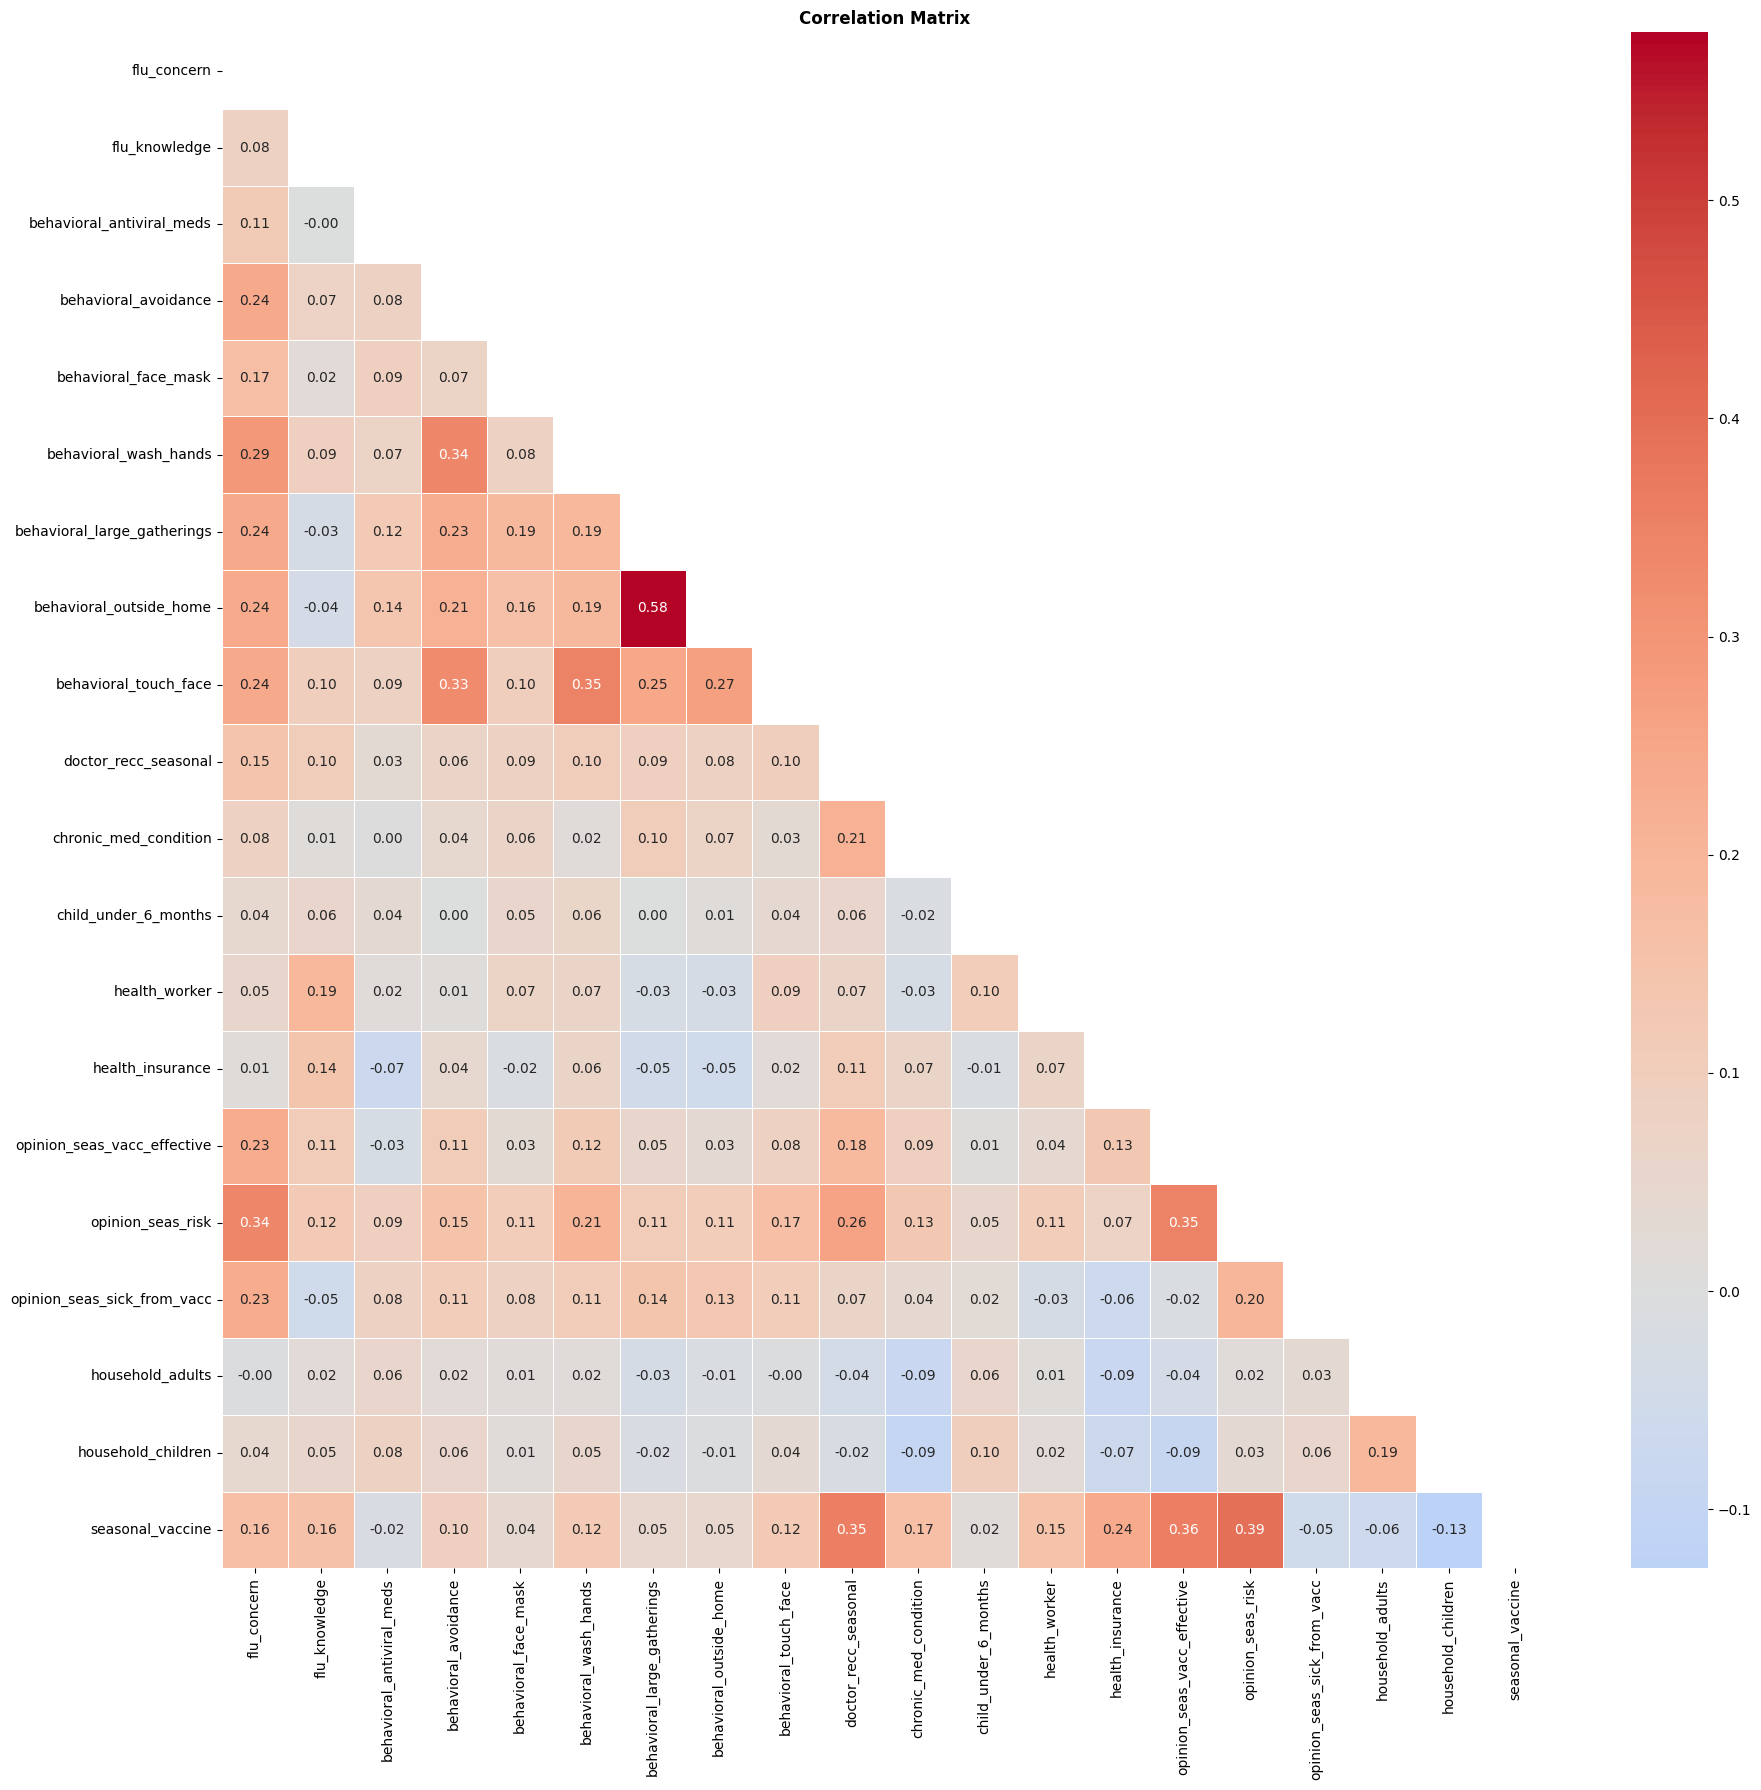

In [ ]:
#  3.5 Correlation Heatmap (numeric features)
num_cols = df_vaccine.select_dtypes(include=np.number).columns.tolist()
if Target_variable in num_cols:
    num_cols.remove(Target_variable )

if len(num_cols) > 1:
    corr = df_vaccine[num_cols + [Target_variable ]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols)-1)))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Correlation Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()


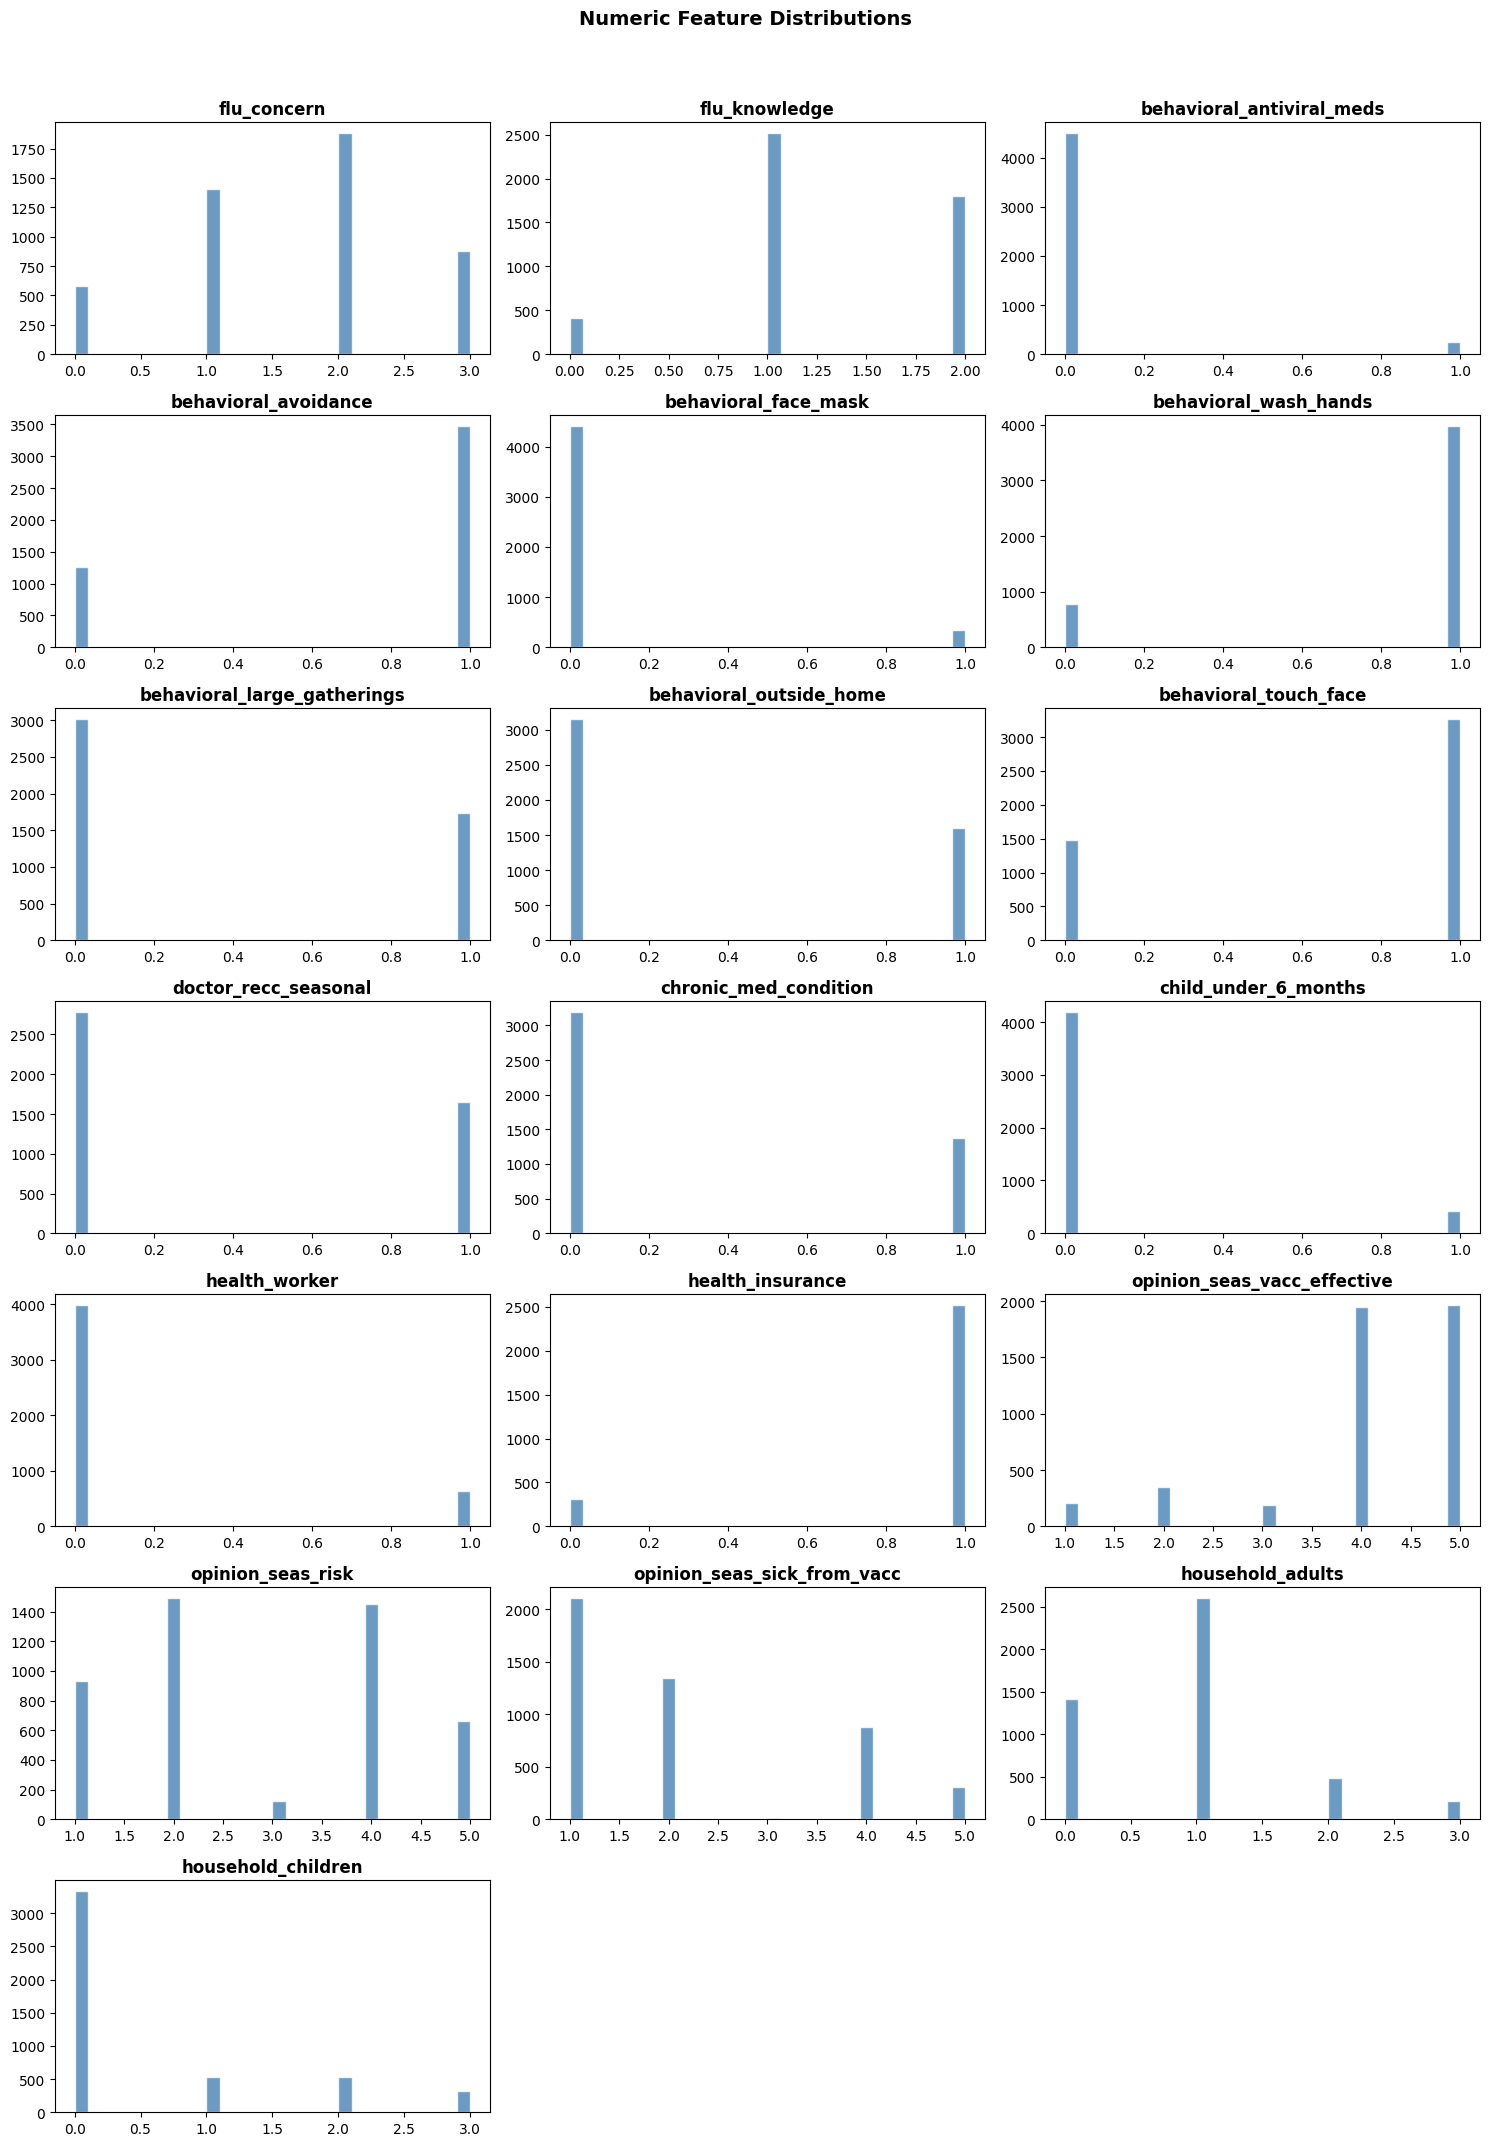

In [ ]:
# Numeric Feature Distributions
if len(num_cols) > 0:
    n_cols = 3
    n_rows = (len(num_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        axes[i].hist(df_vaccine[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()